## University of Information Technology and Sciences
Name :Sabbir Ahmed Rony

Id:0432310005101069

Section :7B1

Batch:53

Course Title: Simulation & Modeling Lab

Course Code: CSE 413 (Autumn 25)



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


data = {
    'Customer_ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
    'Daily_Arrivals': [8, 12, 10, 15, 9, 13, 11, 14, 7, 16, 10, 12, 9, 15, 11, 13, 14, 8, 12, 10]
}

df = pd.DataFrame(data)
print("Original Data:")
display(df.head())

Original Data:


,Customer_ID,Daily_Arrivals
0,1,8
1,2,12
2,3,10
3,4,15
4,5,9


### 1. Basic Statistics

In [10]:
s
mean_arrivals = df['Daily_Arrivals'].mean()
sample_variance = df['Daily_Arrivals'].var(ddof=1)
population_variance = df['Daily_Arrivals'].var(ddof=0)
sample_std = df['Daily_Arrivals'].std(ddof=1)
population_std = df['Daily_Arrivals'].std(ddof=0)

print(f"Mean Daily Arrivals: {mean_arrivals:.2f}")
print(f"Sample Variance: {sample_variance:.2f}")
print(f"Population Variance: {population_variance:.2f}")
print(f"Sample Standard Deviation: {sample_std:.2f}")
print(f"Population Standard Deviation: {population_std:.2f}")

Mean Daily Arrivals: 11.45
Sample Variance: 6.68
Population Variance: 6.35
Sample Standard Deviation: 2.58
Population Standard Deviation: 2.52


#### Comparison: Population Variance vs. Sample Variance

*   **Population Variance** ($\sigma^2$): This is calculated when you have data for *every single member* of an entire group (the population). It uses the total number of observations, 'N', in its denominator. If our 20 days of data represent the entire universe of daily arrivals we are interested in, then this would be appropriate.

*   **Sample Variance** ($s^2$): This is calculated when you only have data for a *subset* (a sample) of a larger population. It uses 'n-1' in its denominator (Bessel's correction). This correction provides an unbiased estimate of the true population variance, which is generally unknown. In most real-world scenarios, we work with samples, so sample variance is more commonly used for inferential statistics.



### 2. Random Number Generation

In [11]:

min_arrival = df['Daily_Arrivals'].min()
max_arrival = df['Daily_Arrivals'].max()

n_simulated_days = 30

generated_arrivals = np.random.randint(low=min_arrival, high=max_arrival + 1, size=n_simulated_days)
generated_df = pd.DataFrame({'Daily_Arrivals': generated_arrivals})

print("Generated Daily Arrivals (Simulated 30 days):")
display(generated_df.head())

Generated Daily Arrivals (Simulated 30 days):


,Daily_Arrivals
0,12
1,14
2,9
3,16
4,15


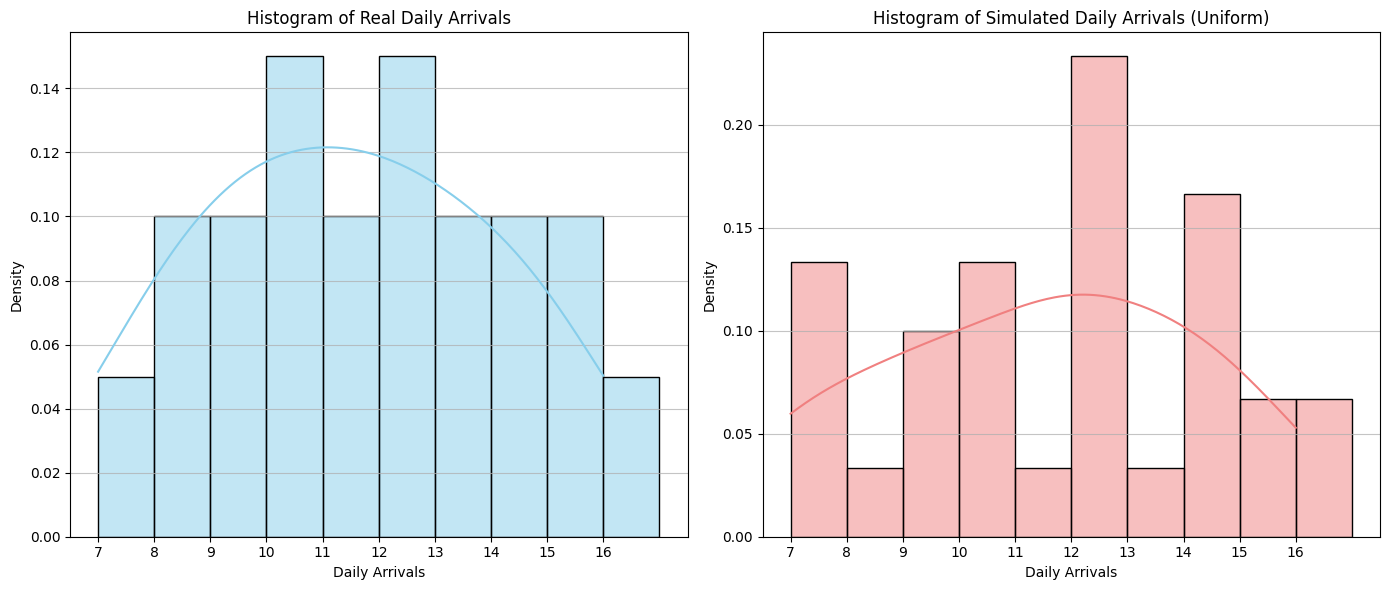

In [12]:

plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
sns.histplot(df['Daily_Arrivals'], bins=range(min_arrival, max_arrival + 2), kde=True, color='skyblue', stat='density')
plt.title('Histogram of Real Daily Arrivals')
plt.xlabel('Daily Arrivals')
plt.ylabel('Density')
plt.xticks(range(min_arrival, max_arrival + 1))
plt.grid(axis='y', alpha=0.75)


plt.subplot(1, 2, 2)
sns.histplot(generated_df['Daily_Arrivals'], bins=range(min_arrival, max_arrival + 2), kde=True, color='lightcoral', stat='density')
plt.title('Histogram of Simulated Daily Arrivals (Uniform)')
plt.xlabel('Daily Arrivals')
plt.ylabel('Density')
plt.xticks(range(min_arrival, max_arrival + 1))
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

### 3. Monte Carlo Simulation

In [13]:


n_simulations = 100000


simulated_arrivals_mc = np.random.randint(low=min_arrival, high=max_arrival + 1, size=n_simulations)


arrivals_gt_15 = (simulated_arrivals_mc > 15).sum()


probability_gt_15 = arrivals_gt_15 / n_simulations

print(f"Number of Monte Carlo simulations: {n_simulations}")
print(f"Number of simulated days with > 15 arrivals: {arrivals_gt_15}")
print(f"Estimated probability of more than 15 customers arriving: {probability_gt_15:.4f}")

Number of Monte Carlo simulations: 100000
Number of simulated days with > 15 arrivals: 9825
Estimated probability of more than 15 customers arriving: 0.0983


In [14]:

student_id_last_3_digits = 69
mu_0 = (student_id_last_3_digits % 10) + 10

print(f"Using student ID last 3 digits: {student_id_last_3_digits}")
print(f"Null Hypothesis (H0) mean (μ_0): {mu_0}")
t_statistic, p_value = stats.ttest_1samp(df['Daily_Arrivals'], popmean=mu_0)

print(f"\nObserved t-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")
alpha = 0.05

print(f"\nSignificance level (α): {alpha}")
if p_value < alpha:
    conclusion = "Reject the null hypothesis."
    interpretation = f"There is sufficient evidence to conclude that the average daily customer arrival ({mean_arrivals:.2f}) is significantly different from the hypothesized mean of {mu_0:.2f}."
else:
    conclusion = "Fail to reject the null hypothesis."
    interpretation = f"There is not enough evidence to conclude that the average daily customer arrival ({mean_arrivals:.2f}) is significantly different from the hypothesized mean of {mu_0:.2f}. We cannot rule out that the true average is {mu_0:.2f}."

print(f"Conclusion: {conclusion}")
print(f"Interpretation: {interpretation}")

Using student ID last 3 digits: 69
Null Hypothesis (H0) mean (μ_0): 19

Observed t-statistic: -13.062
P-value: 0.000

Significance level (α): 0.05
Conclusion: Reject the null hypothesis.
Interpretation: There is sufficient evidence to conclude that the average daily customer arrival (11.45) is significantly different from the hypothesized mean of 19.00.


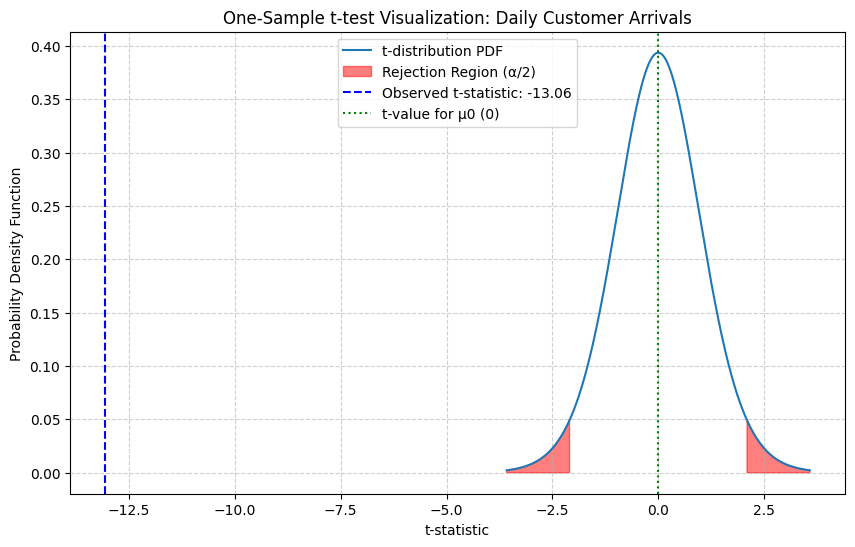


Visual Interpretation:
The blue dashed line (observed t-statistic = -13.06) falls within one of the red shaded rejection regions. This visually confirms our decision to reject the null hypothesis, indicating that our sample mean (11.45) is statistically far enough from the hypothesized mean of 19.00 to be considered significantly different.


In [15]:

df_t = len(df['Daily_Arrivals']) - 1
x = np.linspace(stats.t.ppf(0.001, df_t), stats.t.ppf(0.999, df_t), 1000)

plt.figure(figsize=(10, 6))
plt.plot(x, stats.t.pdf(x, df_t), label='t-distribution PDF')
critical_value_lower = stats.t.ppf(alpha / 2, df_t)
critical_value_upper = stats.t.ppf(1 - alpha / 2, df_t)
plt.fill_between(x, 0, stats.t.pdf(x, df_t), where=(x < critical_value_lower) | (x > critical_value_upper), color='red', alpha=0.5, label='Rejection Region (α/2)')
plt.axvline(t_statistic, color='blue', linestyle='--', label=f'Observed t-statistic: {t_statistic:.2f}')
plt.axvline(0, color='green', linestyle=':', label='t-value for μ0 (0)')

plt.title('One-Sample t-test Visualization: Daily Customer Arrivals')
plt.xlabel('t-statistic')
plt.ylabel('Probability Density Function')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
print("\nVisual Interpretation:")
if p_value < alpha:
    viz_interpretation = f"The blue dashed line (observed t-statistic = {t_statistic:.2f}) falls within one of the red shaded rejection regions. This visually confirms our decision to reject the null hypothesis, indicating that our sample mean ({mean_arrivals:.2f}) is statistically far enough from the hypothesized mean of {mu_0:.2f} to be considered significantly different."
else:
    viz_interpretation = f"The blue dashed line (observed t-statistic = {t_statistic:.2f}) falls outside the red shaded rejection regions. This visually confirms our decision to fail to reject the null hypothesis, suggesting that our sample mean ({mean_arrivals:.2f}) is not statistically different enough from the hypothesized mean of {mu_0:.2f} to claim a significant difference."

print(viz_interpretation)

## Lab Test 1 (Set A) Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

data = {
    'Student_ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
    'Exam_Score': [93, 83, 69, 62, 75, 93, 73, 77, 65, 65, 78, 90, 94, 78, 57, 76, 56, 78, 84, 92]
}

df = pd.DataFrame(data)
display(df.head())


,Student_ID,Exam_Score
0,1,93
1,2,83
2,3,69
3,4,62
4,5,75


### Basic Statistics: Mean, Variance, and Standard Deviation

In [2]:

mean_score = df['Exam_Score'].mean()
sample_variance = df['Exam_Score'].var(ddof=1)
population_variance = df['Exam_Score'].var(ddof=0)
sample_std = df['Exam_Score'].std(ddof=1)
population_std = df['Exam_Score'].std(ddof=0)
print(f"Mean Score: {mean_score:.2f}")
print(f"Sample Variance: {sample_variance:.2f}")
print(f"Population Variance: {population_variance:.2f}")
print(f"Sample Standard Deviation: {sample_std:.2f}")
print(f"Population Standard Deviation: {population_std:.2f}")


Mean Score: 76.90
Sample Variance: 143.25
Population Variance: 136.09
Sample Standard Deviation: 11.97
Population Standard Deviation: 11.67


### Random Number Generation

In [3]:

n_samples = 20
generated_scores = np.random.normal(loc=mean_score, scale=sample_std, size=n_samples)

generated_df = pd.DataFrame({'Exam_Score': generated_scores})

print("Generated Exam Scores:")
display(generated_df.head())


Generated Exam Scores:


,Exam_Score
0,72.084699
1,61.434399
2,79.012813
3,69.029596
4,88.428734


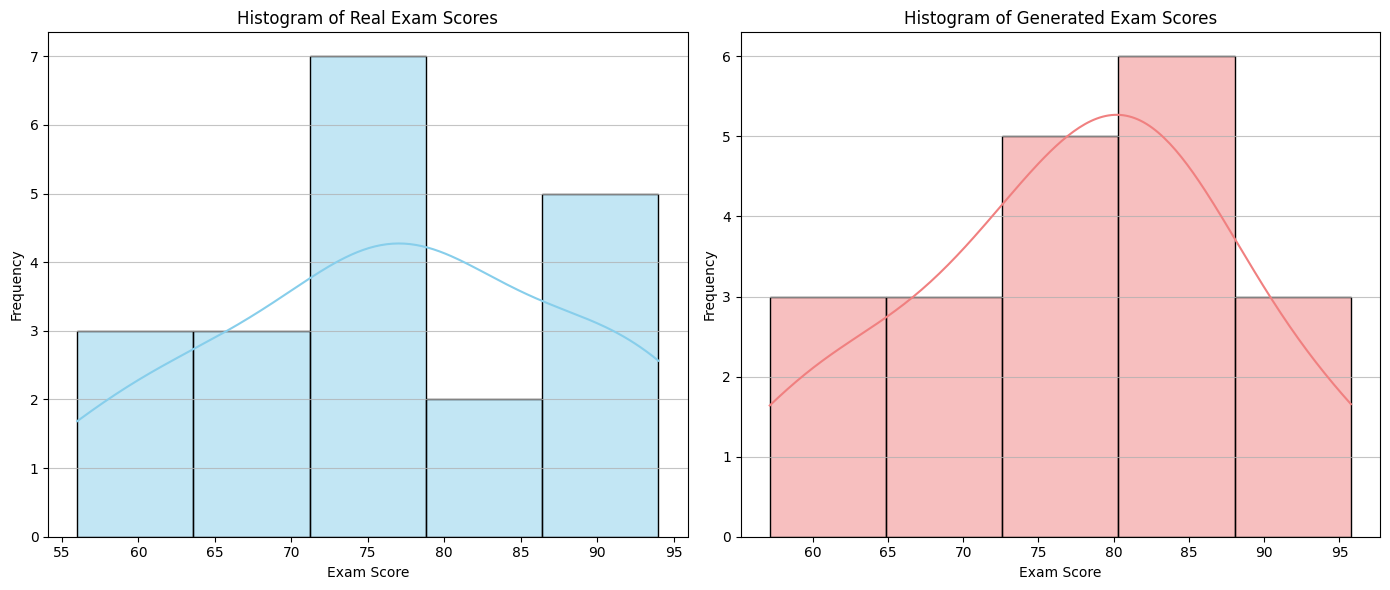

In [4]:

plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
sns.histplot(df['Exam_Score'], bins=5, kde=True, color='skyblue')
plt.title('Histogram of Real Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 2, 2)
sns.histplot(generated_df['Exam_Score'], bins=5, kde=True, color='lightcoral')
plt.title('Histogram of Generated Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()


### Monte Carlo Simulation

In [5]:

n_simulations = 100000


simulated_scores = np.random.normal(loc=mean_score, scale=sample_std, size=n_simulations)


scores_ge_75 = (simulated_scores >= 75).sum()


probability = scores_ge_75 / n_simulations

print(f"Number of simulated scores: {n_simulations}")
print(f"Number of simulated scores >= 75: {scores_ge_75}")
print(f"Estimated probability of scoring >= 75: {probability:.4f}")


Number of simulated scores: 100000
Number of simulated scores >= 75: 56418
Estimated probability of scoring >= 75: 0.5642


In [8]:

student_id_last_3_digits = 69


mu_0 = (student_id_last_3_digits % 50) + 50

print(f"Using student ID last 3 digits: {student_id_last_3_digits}")
print(f"Null Hypothesis (H0) mean (μ_0): {mu_0}")


t_statistic, p_value = stats.ttest_1samp(df['Exam_Score'], popmean=mu_0)

print(f"\nObserved t-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

alpha = 0.05

print(f"\nSignificance level (α): {alpha}")

if p_value < alpha:
    conclusion = "Reject the null hypothesis."
    interpretation = f"There is sufficient evidence to conclude that the average exam score ({mean_score:.2f}) is significantly different from the hypothesized score of {mu_0:.2f}."
else:
    conclusion = "Fail to reject the null hypothesis."
    interpretation = f"There is not enough evidence to conclude that the average exam score ({mean_score:.2f}) is significantly different from the hypothesized score of {mu_0:.2f}. We cannot rule out that the true average is {mu_0:.2f}."

print(f"Conclusion: {conclusion}")
print(f"Interpretation: {interpretation}")

Using student ID last 3 digits: 69
Null Hypothesis (H0) mean (μ_0): 69

Observed t-statistic: 2.952
P-value: 0.008

Significance level (α): 0.05
Conclusion: Reject the null hypothesis.
Interpretation: There is sufficient evidence to conclude that the average exam score (76.90) is significantly different from the hypothesized score of 69.00.


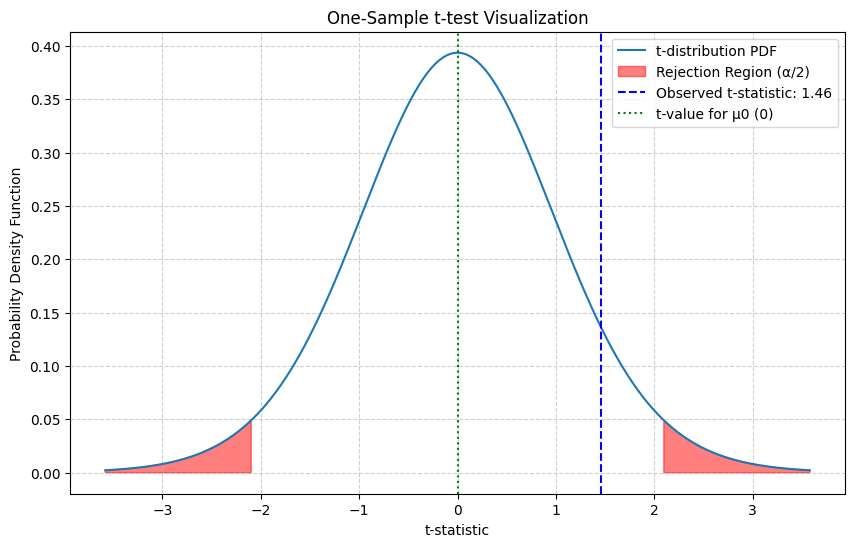


Visual Interpretation:
The blue dashed line (observed t-statistic = 1.46) falls outside the red shaded rejection regions. This visually confirms our decision to fail to reject the null hypothesis, suggesting that our sample mean is not statistically different enough from 73.00 to claim a significant difference.


In [7]:

df_t = len(df['Exam_Score']) - 1


x = np.linspace(stats.t.ppf(0.001, df_t), stats.t.ppf(0.999, df_t), 1000)

plt.figure(figsize=(10, 6))
plt.plot(x, stats.t.pdf(x, df_t), label='t-distribution PDF')


critical_value_lower = stats.t.ppf(alpha / 2, df_t)
critical_value_upper = stats.t.ppf(1 - alpha / 2, df_t)

plt.fill_between(x, 0, stats.t.pdf(x, df_t), where=(x < critical_value_lower) | (x > critical_value_upper), color='red', alpha=0.5, label='Rejection Region (α/2)')

plt.axvline(t_statistic, color='blue', linestyle='--', label=f'Observed t-statistic: {t_statistic:.2f}')


plt.axvline(0, color='green', linestyle=':', label='t-value for μ0 (0)')

plt.title('One-Sample t-test Visualization')
plt.xlabel('t-statistic')
plt.ylabel('Probability Density Function')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


if p_value < alpha:
    viz_interpretation = f"The blue dashed line (observed t-statistic = {t_statistic:.2f}) falls within the red shaded rejection regions. This visually confirms our decision to reject the null hypothesis, indicating that our sample mean is statistically far from {mu_0:.2f}."
else:
    viz_interpretation = f"The blue dashed line (observed t-statistic = {t_statistic:.2f}) falls outside the red shaded rejection regions. This visually confirms our decision to fail to reject the null hypothesis, suggesting that our sample mean is not statistically different enough from {mu_0:.2f} to claim a significant difference."

print("\nVisual Interpretation:")
print(viz_interpretation)
